# Mini-Lab B: Model Explainability — SHAP Analysis & Decision Framework

**Goal:** Train a TF/Keras model on census data, use the SHAP library for local explainability analysis (force plots, summary plots, dependence plots), and build an exam-ready decision framework for Vertex AI's explainability methods.

**Dataset:** Census income (`bigquery-public-data.ml_datasets.census_adult_income`)  
**Model:** Small TF/Keras neural network (differentiable — would support both Sampled Shapley and Integrated Gradients)  
**Training:** Vertex AI CustomJob with prebuilt TF 2.15 container  
**Estimated Cost:** ~$1 (training job only)  
**Estimated Time:** 1.5–2 hours

---

## Parts

1. **Setup + TF Model Training** — Data prep locally, train on Vertex AI, load model back for local use
2. **Local SHAP Analysis** — KernelExplainer for per-instance and global feature attributions
3. **Decision Framework + Cleanup** — ExplanationSpec reference, method selection guide, exam patterns

---

### Exam Relevance

- **ExplanationSpec configuration** — how to attach explanations to a model upload (`ExplanationMetadata` + `ExplanationParameters`)
- **Method selection** — Sampled Shapley (any model) vs Integrated Gradients (differentiable) vs XRAI (images)
- **Feature attributions** — interpreting which features drive individual predictions
- **Stakeholder communication** — "why did the model make this decision?"
- **SHAP library** — the industry-standard open-source tool for model explainability

---
## Part 1: Setup + TF Model Training

We preprocess data locally, then submit training to Vertex AI using the prebuilt TF 2.15 container. This avoids two issues:
- TF 2.20 + Python 3.13 causes `model.fit()` to hang silently on macOS
- The serving container runs TF 2.15 (Keras 2), so training with the same version avoids SavedModel format mismatches

---

### 1.1 Imports and Configuration

In [69]:
# Standard library
import os
import json
import pickle
import datetime

# Data
import numpy as np
import pandas as pd
from google.cloud import bigquery
from google.cloud import storage

# Vertex AI
from google.cloud import aiplatform

# TensorFlow (for loading the trained model locally — inference only)
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__} (local, inference only)")
print(f"Vertex AI SDK version: {aiplatform.__version__}")

TensorFlow version: 2.15.1 (local, inference only)
Vertex AI SDK version: 1.141.0


In [70]:
# === Project Configuration ===
PROJECT_ID = "carty-470812"
REGION = "us-central1"
BUCKET_NAME = PROJECT_ID
BUCKET_URI = f"gs://{BUCKET_NAME}"

TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
LAB_PREFIX = "mini-lab-b-explain"

# GCS paths
DATA_DIR = f"{BUCKET_URI}/{LAB_PREFIX}/data"
MODEL_DIR = f"{BUCKET_URI}/{LAB_PREFIX}/model"

# GCS prefixes (without gs://bucket/) for training script args
DATA_PREFIX = f"{LAB_PREFIX}/data"
MODEL_PREFIX = f"{LAB_PREFIX}/model"

# Containers
TRAIN_CONTAINER = "us-docker.pkg.dev/vertex-ai/training/tf-cpu.2-15.py310:latest"
SERVE_CONTAINER = "us-docker.pkg.dev/vertex-ai/prediction/tf2-cpu.2-15:latest"

print(f"Project:         {PROJECT_ID}")
print(f"Region:          {REGION}")
print(f"Bucket:          {BUCKET_URI}")
print(f"Timestamp:       {TIMESTAMP}")
print(f"Data dir:        {DATA_DIR}")
print(f"Model dir:       {MODEL_DIR}")
print(f"Train container: {TRAIN_CONTAINER}")
print(f"Serve container: {SERVE_CONTAINER}")

Project:         carty-470812
Region:          us-central1
Bucket:          gs://carty-470812
Timestamp:       20260314-195238
Data dir:        gs://carty-470812/mini-lab-b-explain/data
Model dir:       gs://carty-470812/mini-lab-b-explain/model
Train container: us-docker.pkg.dev/vertex-ai/training/tf-cpu.2-15.py310:latest
Serve container: us-docker.pkg.dev/vertex-ai/prediction/tf2-cpu.2-15:latest


In [71]:
# Initialize Vertex AI
aiplatform.init(
    project=PROJECT_ID,
    location=REGION,
    staging_bucket=BUCKET_URI,
)

### 1.2 Load Census Data from BigQuery

In [72]:
bq_client = bigquery.Client(project=PROJECT_ID)

query = """
SELECT
    age,
    workclass,
    education,
    education_num,
    marital_status,
    occupation,
    relationship,
    race,
    sex,
    capital_gain,
    capital_loss,
    hours_per_week,
    native_country,
    income_bracket
FROM
    `bigquery-public-data.ml_datasets.census_adult_income`
WHERE
    workclass IS NOT NULL
    AND education IS NOT NULL
    AND marital_status IS NOT NULL
    AND occupation IS NOT NULL
    AND relationship IS NOT NULL
    AND race IS NOT NULL
    AND native_country IS NOT NULL
"""

df = bq_client.query(query).to_dataframe()
print(f"Dataset shape: {df.shape}")
df.head()

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv-tf/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Dataset shape: (32561, 14)


,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,39,Private,9th,5,Married-civ-spouse,Other-service,Wife,Black,Female,3411,0,34,United-States,<=50K
1,77,Private,9th,5,Married-civ-spouse,Priv-house-serv,Wife,Black,Female,0,0,10,United-States,<=50K
2,38,Private,9th,5,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,24,Haiti,<=50K
3,28,Private,9th,5,Married-civ-spouse,Protective-serv,Wife,Black,Female,0,0,40,United-States,<=50K
4,37,Private,9th,5,Married-civ-spouse,Machine-op-inspct,Wife,Black,Female,0,0,48,United-States,<=50K


In [73]:
# Quick look at the target
df["income_bracket"].value_counts()

income_bracket
<=50K    24720
>50K      7841
Name: count, dtype: int64

### 1.3 Preprocess for TF/Keras

We need numeric inputs for the neural network. We'll:
- Label-encode the target
- One-hot encode categorical features
- Standardize numeric features

**Why do preprocessing outside the model graph?** For this lab, we want the model to accept a simple numeric tensor so that both Vertex AI explanations and local SHAP can work cleanly with named feature attributions. Baking preprocessing into the SavedModel (like Lab 8's base64 pattern) is great for serving but makes explanation interpretation harder.

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Target ---
df["label"] = (df["income_bracket"].str.strip() == ">50K").astype(int)
df = df.drop(columns=["income_bracket"])

print(f"Label distribution:\n{df['label'].value_counts()}")
print(f"\nPositive rate: {df['label'].mean():.1%}")

Label distribution:
label
0    24720
1     7841
Name: count, dtype: int64

Positive rate: 24.1%


In [75]:
# --- Feature engineering ---
# Separate numeric and categorical
NUMERIC_COLS = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
CATEGORICAL_COLS = ["workclass", "education", "marital_status", "occupation",
                    "relationship", "race", "sex", "native_country"]

# One-hot encode categoricals
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True)

# Split features and target
y = df_encoded["label"].values
X = df_encoded.drop(columns=["label"])
FEATURE_NAMES = list(X.columns)

print(f"Number of features after encoding: {len(FEATURE_NAMES)}")
print(f"First 10 features: {FEATURE_NAMES[:10]}")

Number of features after encoding: 99
First 10 features: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass_ Federal-gov', 'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private', 'workclass_ Self-emp-inc']


In [76]:
# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42, stratify=y
)

# --- Standardize numeric columns ---
# Only scale the first len(NUMERIC_COLS) columns (the numeric ones)
# One-hot columns are already 0/1
scaler = StandardScaler()
num_idx = list(range(len(NUMERIC_COLS)))

X_train_scaled = X_train.copy().astype(float)
X_test_scaled = X_test.copy().astype(float)

X_train_scaled[:, num_idx] = scaler.fit_transform(X_train[:, num_idx])
X_test_scaled[:, num_idx] = scaler.transform(X_test[:, num_idx])

print(f"Training set:  {X_train_scaled.shape}")
print(f"Test set:      {X_test_scaled.shape}")

Training set:  (26048, 99)
Test set:      (6513, 99)


### 1.4 Upload Preprocessed Data to GCS

We save the preprocessed numpy arrays to GCS so the Vertex AI training job can access them. We also save the feature names list — we'll need it for ExplanationMetadata.

In [77]:
# Save preprocessed data locally
LOCAL_DATA_DIR = "data_artifact"
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

np.save(f"{LOCAL_DATA_DIR}/X_train.npy", X_train_scaled)
np.save(f"{LOCAL_DATA_DIR}/X_test.npy", X_test_scaled)
np.save(f"{LOCAL_DATA_DIR}/y_train.npy", y_train)
np.save(f"{LOCAL_DATA_DIR}/y_test.npy", y_test)

with open(f"{LOCAL_DATA_DIR}/feature_names.pkl", "wb") as f:
    pickle.dump(FEATURE_NAMES, f, protocol=4)  # protocol 4 for Python 3.10 compat

# Upload to GCS
!gsutil -m cp -r {LOCAL_DATA_DIR}/* {DATA_DIR}/

print(f"\nData uploaded to {DATA_DIR}/")
!gsutil ls {DATA_DIR}/

If you experience problems with multiprocessing on MacOS, they might be related to https://bugs.python.org/issue33725. You can disable multiprocessing by editing your .boto config or by adding the following flag to your command: `-o "GSUtil:parallel_process_count=1"`. Note that multithreading is still available even if you disable multiprocessing.

Copying file://data_artifact/feature_names.pkl [Content-Type=application/octet-stream]...
Copying file://data_artifact/X_train.npy [Content-Type=application/octet-stream]...
Copying file://data_artifact/X_test.npy [Content-Type=application/octet-stream]...
Copying file://data_artifact/y_train.npy [Content-Type=application/octet-stream]...
Copying file://data_artifact/y_test.npy [Content-Type=application/octet-stream]...
| [5/5 files][ 24.8 MiB/ 24.8 MiB] 100% Done                                    
Operation completed over 5 objects/24.8 MiB.                                     

Data uploaded to gs://carty-470812/mini-lab-b-explain/data/
g

### 1.5 Write Training Script

This script runs inside the Vertex AI prebuilt TF 2.15 container (Python 3.10, Keras 2). It:
1. Loads the preprocessed data from GCS
2. Trains a small Keras Sequential model
3. Evaluates on the test set
4. Saves the model as SavedModel format to GCS

**Why Keras?** Integrated Gradients requires a differentiable model — it computes gradients of the output with respect to inputs. Sklearn models don't have gradients, so they only support Sampled Shapley on Vertex AI.

In [78]:
%%writefile train_census_keras.py
"""Training script for Mini-Lab B: Census income Keras model.

Runs on Vertex AI with prebuilt TF 2.15 container.
"""
import argparse
import json
import os
import pickle

import numpy as np
import tensorflow as tf
from tensorflow import keras
from google.cloud import storage

print(f"TensorFlow version: {tf.__version__}")


def download_blob(bucket_name, source_blob, dest_file):
    """Download a file from GCS."""
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(source_blob)
    blob.download_to_filename(dest_file)
    print(f"Downloaded gs://{bucket_name}/{source_blob} -> {dest_file}")


def upload_directory(local_dir, bucket_name, gcs_prefix):
    """Upload a local directory to GCS."""
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    for root, dirs, files in os.walk(local_dir):
        for filename in files:
            local_path = os.path.join(root, filename)
            relative_path = os.path.relpath(local_path, local_dir)
            blob_path = f"{gcs_prefix}/{relative_path}"
            blob = bucket.blob(blob_path)
            blob.upload_from_filename(local_path)
            print(f"Uploaded {local_path} -> gs://{bucket_name}/{blob_path}")


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--bucket-name", required=True)
    parser.add_argument("--data-dir", required=True, help="GCS prefix for data files")
    parser.add_argument("--model-dir", required=True, help="GCS prefix for model output")
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--batch-size", type=int, default=256)
    parser.add_argument("--learning-rate", type=float, default=0.001)
    args = parser.parse_args()

    # --- Download data from GCS ---
    os.makedirs("/tmp/data", exist_ok=True)
    for fname in ["X_train.npy", "X_test.npy", "y_train.npy", "y_test.npy", "feature_names.pkl"]:
        download_blob(args.bucket_name, f"{args.data_dir}/{fname}", f"/tmp/data/{fname}")

    X_train = np.load("/tmp/data/X_train.npy")
    X_test = np.load("/tmp/data/X_test.npy")
    y_train = np.load("/tmp/data/y_train.npy")
    y_test = np.load("/tmp/data/y_test.npy")

    with open("/tmp/data/feature_names.pkl", "rb") as f:
        feature_names = pickle.load(f)

    n_features = X_train.shape[1]
    print(f"\nTraining data: {X_train.shape}")
    print(f"Test data: {X_test.shape}")
    print(f"Features: {n_features}")

    # --- Build model ---
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features,), name="input_features"),
        keras.layers.Dense(64, activation="relu", name="hidden_1"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation="relu", name="hidden_2"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation="sigmoid", name="output"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=args.learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    model.summary()

    # --- Train ---
    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=args.epochs,
        batch_size=args.batch_size,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=3, restore_best_weights=True
            )
        ],
        verbose=1,
    )

    # --- Evaluate ---
    y_pred_proba = model.predict(X_test).flatten()
    y_pred = (y_pred_proba >= 0.5).astype(int)
    accuracy = float((y_pred == y_test).mean())

    from sklearn.metrics import roc_auc_score
    roc_auc = float(roc_auc_score(y_test, y_pred_proba))

    print(f"\nTest accuracy: {accuracy:.4f}")
    print(f"Test ROC AUC:  {roc_auc:.4f}")

    # --- Save metrics ---
    metrics = {
        "accuracy": accuracy,
        "roc_auc": roc_auc,
        "epochs_trained": len(history.history["loss"]),
    }
    with open("/tmp/metrics.json", "w") as f:
        json.dump(metrics, f)

    client = storage.Client()
    bucket = client.bucket(args.bucket_name)
    blob = bucket.blob(f"{args.model_dir}/metrics.json")
    blob.upload_from_filename("/tmp/metrics.json")
    print(f"Metrics saved to gs://{args.bucket_name}/{args.model_dir}/metrics.json")

    # --- Save model as SavedModel ---
    local_model_dir = "/tmp/model_output"
    model.save(local_model_dir)
    print(f"\nModel saved locally to {local_model_dir}")

    # Upload to GCS
    upload_directory(local_model_dir, args.bucket_name, args.model_dir)
    print(f"\nModel uploaded to gs://{args.bucket_name}/{args.model_dir}/")


if __name__ == "__main__":
    main()

Writing train_census_keras.py


### 1.6 Submit Training Job to Vertex AI

Using the prebuilt TF 2.15 container — same version as our serving container. This avoids the Keras 2/3 SavedModel mismatch AND the Python 3.13 training hang.

In [79]:
from google.cloud.aiplatform import CustomJob

job = CustomJob.from_local_script(
    display_name=f"{LAB_PREFIX}-train-{TIMESTAMP}",
    script_path="train_census_keras.py",
    container_uri=TRAIN_CONTAINER,
    args=[
        "--bucket-name", BUCKET_NAME,
        "--data-dir", DATA_PREFIX,
        "--model-dir", MODEL_PREFIX,
        "--epochs", "30",
        "--batch-size", "256",
        "--learning-rate", "0.001",
    ],
    requirements=["scikit-learn", "google-cloud-storage"],
    replica_count=1,
    machine_type="n1-standard-4",
)

job.run(sync=True)
print("\nTraining job complete!")

Training script copied to:
gs://carty-470812/aiplatform-2026-03-14-19:53:03.855-aiplatform_custom_trainer_script-0.1.tar.gz.
Creating CustomJob
CustomJob created. Resource name: projects/873708835509/locations/us-central1/customJobs/6050600513282506752
To use this CustomJob in another session:
custom_job = aiplatform.CustomJob.get('projects/873708835509/locations/us-central1/customJobs/6050600513282506752')
View Custom Job:
https://console.cloud.google.com/ai/platform/locations/us-central1/training/6050600513282506752?project=873708835509
CustomJob projects/873708835509/locations/us-central1/customJobs/6050600513282506752 current state:
JobState.JOB_STATE_PENDING
CustomJob projects/873708835509/locations/us-central1/customJobs/6050600513282506752 current state:
JobState.JOB_STATE_PENDING
CustomJob projects/873708835509/locations/us-central1/customJobs/6050600513282506752 current state:
JobState.JOB_STATE_PENDING
CustomJob projects/873708835509/locations/us-central1/customJobs/605060051

### 1.7 Verify Model Artifact + Retrieve Metrics

In [80]:
# Check model artifact on GCS
print("Model artifacts:")
!gsutil ls {MODEL_DIR}/

Model artifacts:
gs://carty-470812/mini-lab-b-explain/model/
gs://carty-470812/mini-lab-b-explain/model/fingerprint.pb
gs://carty-470812/mini-lab-b-explain/model/keras_metadata.pb
gs://carty-470812/mini-lab-b-explain/model/metrics.json
gs://carty-470812/mini-lab-b-explain/model/saved_model.pb
gs://carty-470812/mini-lab-b-explain/model/variables/


In [81]:
# Download and display metrics
!gsutil cp {MODEL_DIR}/metrics.json model_artifact/metrics.json

with open("model_artifact/metrics.json") as f:
    metrics = json.load(f)

print(f"Training results:")
print(f"  Accuracy:       {metrics['accuracy']:.4f}")
print(f"  ROC AUC:        {metrics['roc_auc']:.4f}")
print(f"  Epochs trained: {metrics['epochs_trained']}")

Copying gs://carty-470812/mini-lab-b-explain/model/metrics.json...
/ [1 files][   85.0 B/   85.0 B]                                                
Operation completed over 1 objects/85.0 B.                                       
Training results:
  Accuracy:       0.8583
  ROC AUC:        0.9145
  Epochs trained: 10


In [82]:
# Download model and inspect SavedModel signature
# We need the exact tensor names for ExplanationMetadata
LOCAL_MODEL_DIR = "model_artifact"
os.makedirs(LOCAL_MODEL_DIR, exist_ok=True)

!gsutil -o "GSUtil:parallel_process_count=1" -m cp -r "{MODEL_DIR}/*" {LOCAL_MODEL_DIR}/

!saved_model_cli show --dir {LOCAL_MODEL_DIR} --tag_set serve --signature_def serving_default

Copying gs://carty-470812/mini-lab-b-explain/model/fingerprint.pb...
Copying gs://carty-470812/mini-lab-b-explain/model/keras_metadata.pb...         
Copying gs://carty-470812/mini-lab-b-explain/model/metrics.json...              
Copying gs://carty-470812/mini-lab-b-explain/model/variables/variables.data-00000-of-00001...
Copying gs://carty-470812/mini-lab-b-explain/model/saved_model.pb...            
Copying gs://carty-470812/mini-lab-b-explain/model/variables/variables.index... 
The given SavedModel SignatureDef contains the following input(s):              
  inputs['input_features'] tensor_info:
      dtype: DT_FLOAT
      shape: (-1, 99)
      name: serving_default_input_features:0
The given SavedModel SignatureDef contains the following output(s):
  outputs['output'] tensor_info:
      dtype: DT_FLOAT
      shape: (-1, 1)
      name: StatefulPartitionedCall:0
Method name is: tensorflow/serving/predict


**Note the input and output tensor names** from the output above. We'll use these in `ExplanationMetadata`. Typically for a Keras Sequential model:
- Input: `input_features` (from our `Input` layer name)
- Output: `output` (from our last Dense layer name)

### 1.8 Load Model Locally + Select Explanation Instances

We need the model locally for Part 3 (local SHAP). Since it's a TF 2.15/Keras 2 SavedModel, we load it with `tf.saved_model.load()` rather than `keras.models.load_model()` to avoid Keras 2/3 format issues.

In [83]:
# Load the model locally for predictions and SHAP (Part 3)
# Use tf.saved_model.load — works across Keras versions
loaded_model = tf.saved_model.load(LOCAL_MODEL_DIR)
predict_fn_raw = loaded_model.signatures["serving_default"]

# Figure out the output key from the signature
test_input = tf.constant(X_test_scaled[:1].astype(np.float32))
test_output = predict_fn_raw(input_features=test_input)
OUTPUT_KEY = list(test_output.keys())[0]
print(f"Output key: {OUTPUT_KEY}")

# Wrap in a clean prediction function
def predict_fn(x):
    """Predict function compatible with SHAP and analysis code."""
    tensor = tf.constant(x.astype(np.float32))
    result = predict_fn_raw(input_features=tensor)
    return result[OUTPUT_KEY].numpy().flatten()

# Verify it works
sample_preds = predict_fn(X_test_scaled[:5])
print(f"Sample predictions: {sample_preds}")

Output key: output
Sample predictions: [0.23398694 0.22607154 0.5146735  0.5777326  0.21373086]


In [84]:
# Get predictions on full test set
from sklearn.metrics import classification_report, roc_auc_score

y_pred_proba = predict_fn(X_test_scaled)
y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      4945
        >50K       0.75      0.62      0.68      1568

    accuracy                           0.86      6513
   macro avg       0.82      0.78      0.79      6513
weighted avg       0.85      0.86      0.85      6513

ROC AUC: 0.9145


In [85]:
# Find interesting test instances for explanations
high_conf_pos = np.argmax(y_pred_proba)
high_conf_neg = np.argmin(y_pred_proba)
boundary_idx = np.argmin(np.abs(y_pred_proba - 0.5))

EXPLAIN_INDICES = [high_conf_pos, high_conf_neg, boundary_idx]
EXPLAIN_LABELS = ["High confidence >50K", "High confidence <=50K", "Near boundary"]

for idx, label in zip(EXPLAIN_INDICES, EXPLAIN_LABELS):
    print(f"{label}: index={idx}, pred={y_pred_proba[idx]:.4f}, actual={y_test[idx]}")

# Store the scaled instances for explanation requests
explain_instances = X_test_scaled[EXPLAIN_INDICES]

High confidence >50K: index=104, pred=1.0000, actual=1
High confidence <=50K: index=6341, pred=0.0000, actual=0
Near boundary: index=1949, pred=0.4996, actual=0


### 1.9 Log to Experiments

In [86]:
EXPERIMENT_NAME = f"{LAB_PREFIX}-{TIMESTAMP}"

aiplatform.init(
    project=PROJECT_ID,
    location=REGION,
    experiment=EXPERIMENT_NAME,
)

with aiplatform.start_run(run=f"keras-census-{TIMESTAMP}"):
    aiplatform.log_params({
        "model_type": "keras_sequential",
        "hidden_layers": 2,
        "hidden_units": "64-32",
        "dropout": "0.3-0.2",
        "learning_rate": 0.001,
        "batch_size": 256,
        "n_features": len(FEATURE_NAMES),
        "training_container": TRAIN_CONTAINER,
    })
    aiplatform.log_metrics(metrics)

print(f"Logged to experiment: {EXPERIMENT_NAME}")

Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/mini-lab-b-explain-20260314-195238-keras-census-20260314-195238 to Experiment: mini-lab-b-explain-20260314-195238


Logged to experiment: mini-lab-b-explain-20260314-195238


---
## Part 2: Local SHAP Analysis

The SHAP (SHapley Additive exPlanations) library is the industry standard for model explainability. It provides:
- **Force plots** — how features push individual predictions above/below the baseline
- **Summary plots** — global feature importance across the dataset
- **Dependence plots** — how individual feature values affect predictions

We use `KernelExplainer` — the model-agnostic method that approximates Shapley values by sampling feature subsets. This is conceptually identical to Vertex AI's Sampled Shapley method.

---

In [87]:
# Install shap if needed
!pip install shap --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [88]:
import shap

print(f"SHAP version: {shap.__version__}")

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv-tf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.49.1


### 2.1 SHAP KernelExplainer

We use `KernelExplainer` — the model-agnostic version — so it's comparable to Vertex AI's Sampled Shapley. Both approximate Shapley values by sampling.

**Note:** KernelExplainer is slow on large datasets. We use a small background sample (100 instances) to approximate the expected value.

In [89]:
# Use a subsample as the background dataset for SHAP
# This represents the "average" prediction that attributions are relative to
np.random.seed(42)
background_idx = np.random.choice(len(X_train_scaled), size=100, replace=False)
background = X_train_scaled[background_idx]

# Create the explainer using our loaded SavedModel predict function
explainer = shap.KernelExplainer(predict_fn, background)
print("KernelExplainer ready.")
print(f"Background sample: {background.shape[0]} instances")
print(f"Expected value (baseline): {explainer.expected_value:.4f}")

KernelExplainer ready.
Background sample: 100 instances
Expected value (baseline): 0.2207


In [90]:
# Compute SHAP values for our 3 explanation instances
# This takes a minute or two — KernelExplainer is computationally expensive
print("Computing SHAP values for 3 instances (this may take 1-2 minutes)...")
shap_values_explain = explainer.shap_values(explain_instances, nsamples=200)

print(f"SHAP values shape: {shap_values_explain.shape}")
print(f"Features: {len(FEATURE_NAMES)}")

Computing SHAP values for 3 instances (this may take 1-2 minutes)...


100%|██████████| 3/3 [00:00<00:00, 36.15it/s]

SHAP values shape: (3, 99)
Features: 99


### 2.2 Force Plot — Individual Predictions

Force plots show how each feature pushes the prediction away from the baseline (average prediction). Red features push toward >50K (higher output), blue push toward <=50K (lower output).

In [91]:
# Initialize SHAP JS visualization
shap.initjs()

Force plot: High confidence >50K (pred=1.0000)


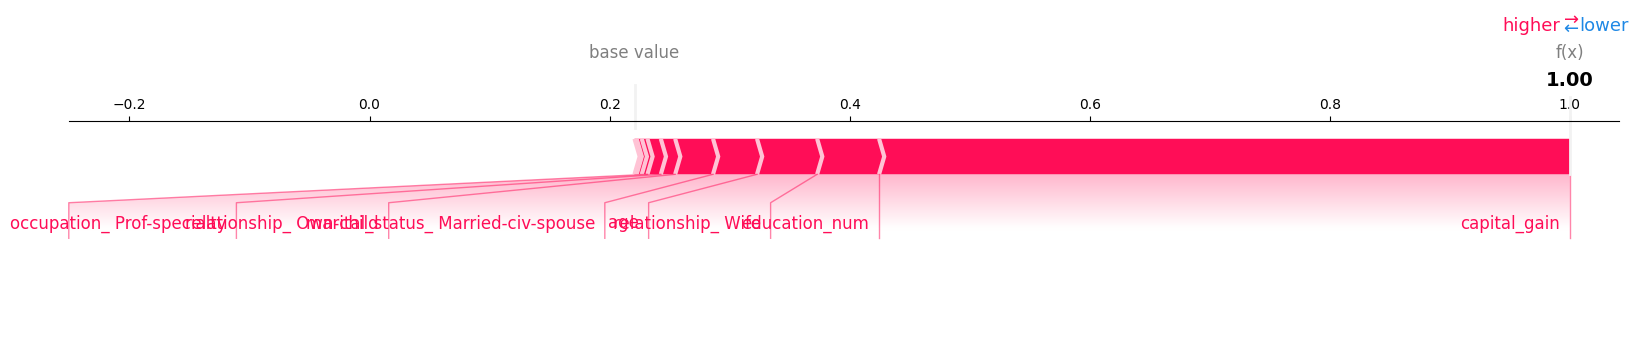

In [95]:
import matplotlib.pyplot as plt

# Force plot for the high confidence >50K instance
print(f"Force plot: {EXPLAIN_LABELS[0]} (pred={y_pred_proba[EXPLAIN_INDICES[0]]:.4f})")
shap.force_plot(
    explainer.expected_value,
    shap_values_explain[0],
    feature_names=FEATURE_NAMES,
    matplotlib=True,
)
plt.show()

Force plot: High confidence <=50K (pred=0.0000)


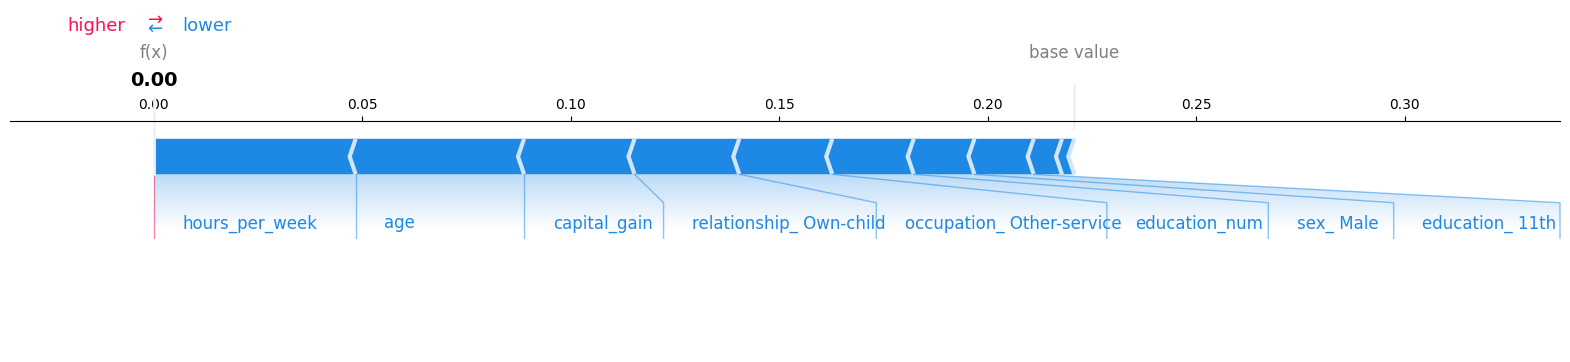

In [96]:
# Force plot for the high confidence <=50K instance
print(f"Force plot: {EXPLAIN_LABELS[1]} (pred={y_pred_proba[EXPLAIN_INDICES[1]]:.4f})")
shap.force_plot(
    explainer.expected_value,
    shap_values_explain[1],
    feature_names=FEATURE_NAMES,
    matplotlib=True,
)
plt.show()

Force plot: Near boundary (pred=0.4996)


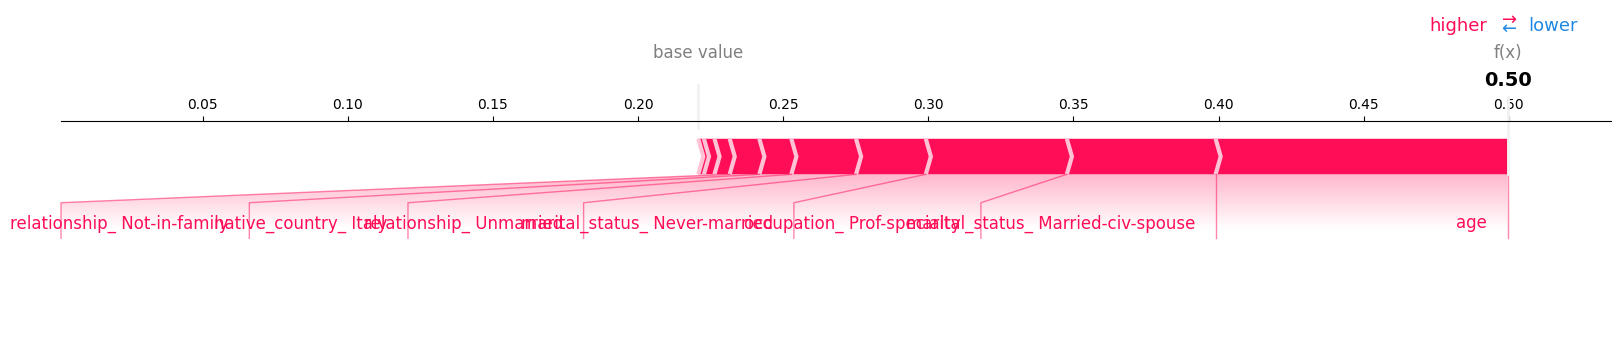

In [97]:
# Force plot for the near-boundary instance
print(f"Force plot: {EXPLAIN_LABELS[2]} (pred={y_pred_proba[EXPLAIN_INDICES[2]]:.4f})")
shap.force_plot(
    explainer.expected_value,
    shap_values_explain[2],
    feature_names=FEATURE_NAMES,
    matplotlib=True,
)
plt.show()

### 2.3 Summary Plot — Global Feature Importance

To get a global view, we compute SHAP values on a larger sample of the test set.

In [98]:
# Compute SHAP values on a larger test sample for global analysis
# Using 200 instances — balance between insight and computation time
np.random.seed(42)
global_idx = np.random.choice(len(X_test_scaled), size=200, replace=False)
X_global = X_test_scaled[global_idx]

print("Computing SHAP values for 200 test instances (this may take several minutes)...")
shap_values_global = explainer.shap_values(X_global, nsamples=100)
print(f"Done! Shape: {shap_values_global.shape}")

Computing SHAP values for 200 test instances (this may take several minutes)...


100%|██████████| 200/200 [00:02<00:00, 69.19it/s]

Done! Shape: (200, 99)


/var/folders/gm/vjgn8n7j4jq6v03c3nq66t8m0000gn/T/ipykernel_36178/4012902437.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


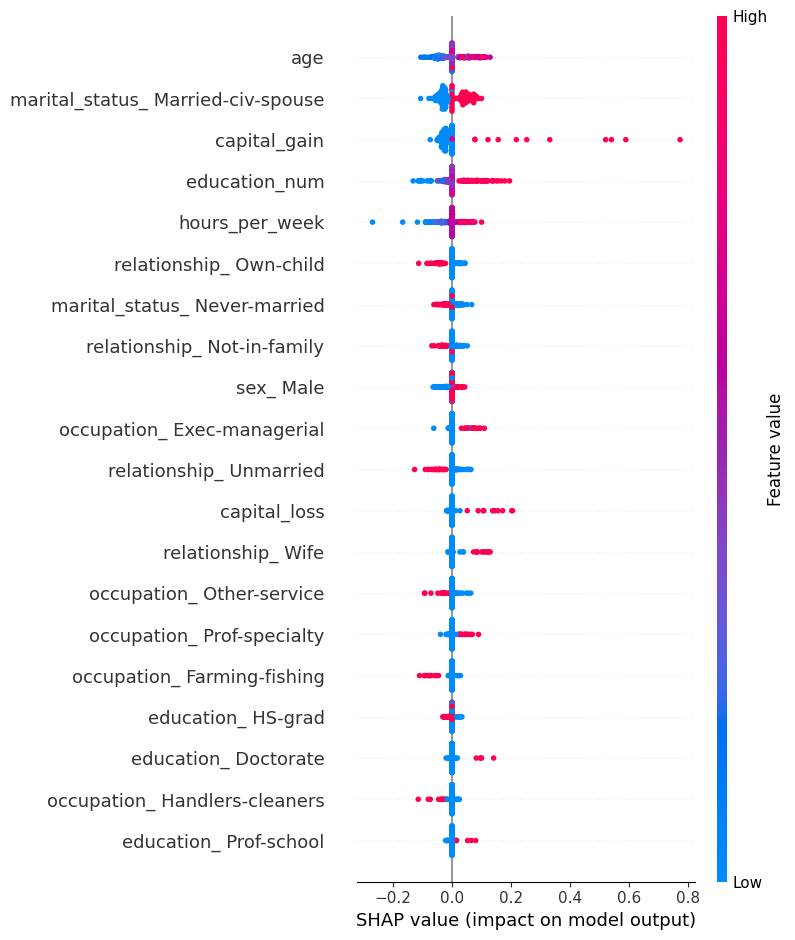

In [99]:
# Summary plot — shows global feature importance AND direction of impact
# Each dot is one instance. Color = feature value (red=high, blue=low)
# Position on x-axis = SHAP value (impact on prediction)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_global,
    features=X_global,
    feature_names=FEATURE_NAMES,
    max_display=20,
    show=True,
)

/var/folders/gm/vjgn8n7j4jq6v03c3nq66t8m0000gn/T/ipykernel_36178/1308250602.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


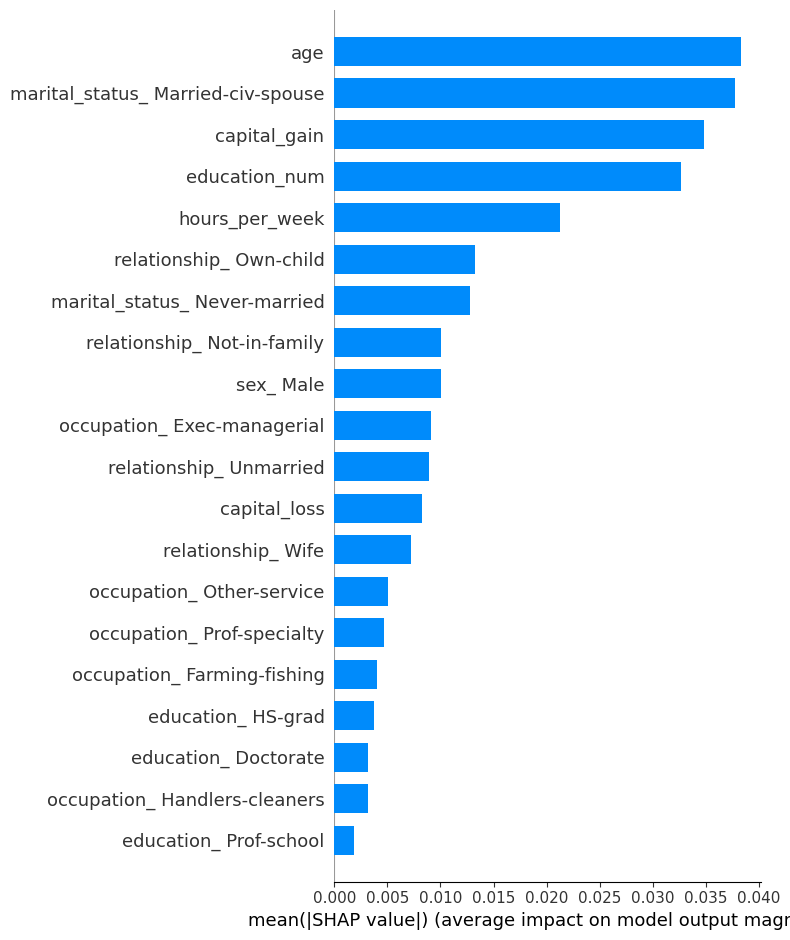

In [100]:
# Bar plot — simpler view of mean absolute SHAP value per feature
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_global,
    features=X_global,
    feature_names=FEATURE_NAMES,
    plot_type="bar",
    max_display=20,
    show=True,
)

### 2.4 Dependence Plot — Feature Interactions

Dependence plots show how a single feature's value affects the prediction. The color automatically picks the feature with the strongest interaction.

<Figure size 800x500 with 0 Axes>

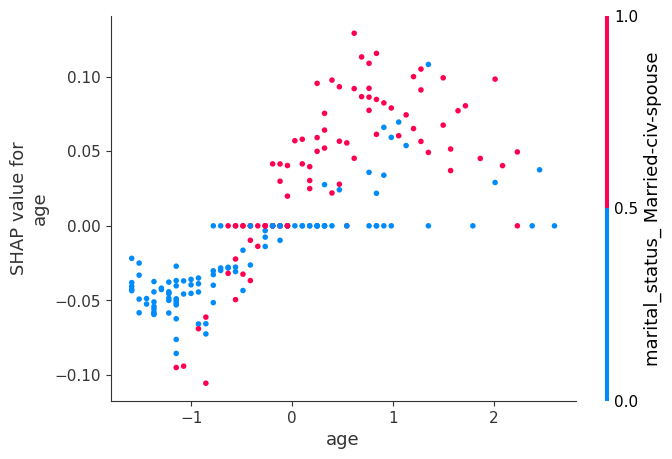

<Figure size 800x500 with 0 Axes>

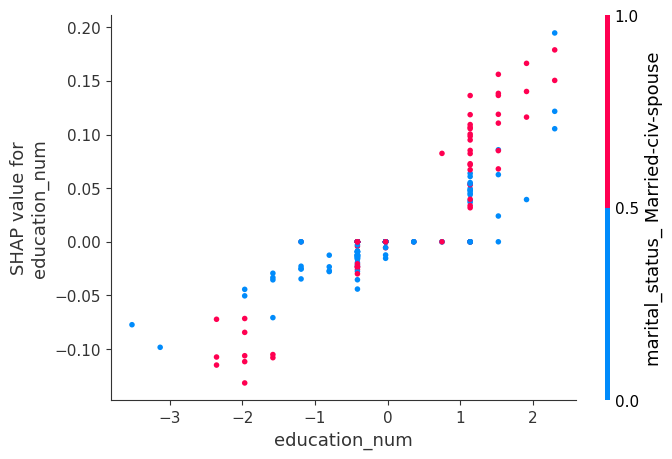

<Figure size 800x500 with 0 Axes>

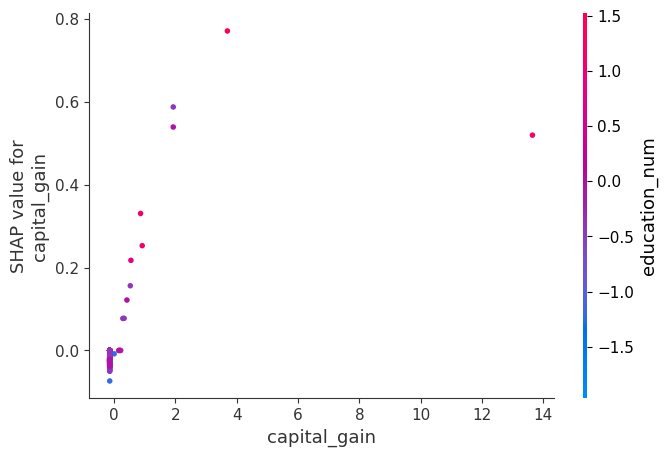

<Figure size 800x500 with 0 Axes>

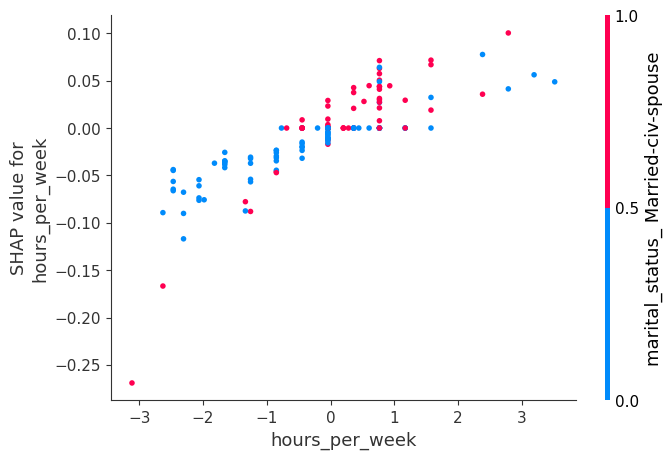

In [101]:
# Dependence plots for top numeric features
for col in ["age", "education_num", "capital_gain", "hours_per_week"]:
    if col in FEATURE_NAMES:
        col_idx = FEATURE_NAMES.index(col)
        plt.figure(figsize=(8, 5))
        shap.dependence_plot(
            col_idx,
            shap_values_global,
            X_global,
            feature_names=FEATURE_NAMES,
            show=True,
        )

---
## Part 3: Decision Framework + Cleanup

---

### 3.1 Vertex AI ExplanationSpec — Configuration Reference

Vertex AI provides built-in explainability through `ExplanationSpec`, configured at **model upload time** (not deploy time). Two components:

**`ExplanationParameters`** — which method to use:
```python
from google.cloud.aiplatform.explain import ExplanationParameters

# Sampled Shapley — works with ANY model
params_shapley = ExplanationParameters(
    {"sampled_shapley_attribution": {"path_count": 25}}
)

# Integrated Gradients — requires differentiable model (TF/Keras)
params_ig = ExplanationParameters(
    {"integrated_gradients_attribution": {"step_count": 50}}
)
```

**`ExplanationMetadata`** — maps tensors to feature names (optional for TF2 models):
```python
from google.cloud.aiplatform.explain import ExplanationMetadata

metadata = ExplanationMetadata(
    inputs={
        "input_features": ExplanationMetadata.InputMetadata(
            input_tensor_name="input_features",
            index_feature_mapping=FEATURE_NAMES,  # maps positions to names
        )
    },
    outputs={
        "output": ExplanationMetadata.OutputMetadata(
            output_tensor_name="output",
        )
    },
)
```

**Attaching to a model:**
```python
model = aiplatform.Model.upload(
    display_name="my-model",
    artifact_uri="gs://bucket/model/",
    serving_container_image_uri=SERVE_CONTAINER,
    explanation_metadata=metadata,       # optional for TF2
    explanation_parameters=params_shapley,  # required
)
```

**Requesting explanations:**
```python
response = endpoint.explain(instances=instances)
# response.explanations[i].attributions[0].feature_attributions
# response.explanations[i].attributions[0].approximation_error
```

**Key exam points:**
- `ExplanationSpec` is set at **model upload**, not deploy time
- To change methods, upload a new model resource (can reuse the same GCS artifacts)
- `explain()` returns attributions alongside predictions — slight latency overhead vs `predict()`
- For TF2 models, `ExplanationMetadata` is optional — Vertex AI auto-infers tensors
- `input_tensor_name` should match the SavedModel serving signature key names
- `index_feature_mapping` maps positional indices to human-readable feature names
- `path_count` (Shapley, range 1-50) and `step_count` (IG, range 1-100) control accuracy vs cost
- Check `approximation_error` — if > 0.05, increase path_count or step_count

### 3.2 Explainability Method Decision Framework

| Method | Model Types | How It Works | Best For | Speed |
|--------|------------|-------------|----------|-------|
| **Sampled Shapley** | Any (sklearn, TF, XGBoost, etc.) | Samples feature subsets to approximate Shapley values | Tabular data, model-agnostic needs | Slower (scales with features x path_count) |
| **Integrated Gradients** | Differentiable only (TF/Keras, PyTorch) | Integrates gradients along path from baseline to input | Neural networks, tabular + structured data | Faster for neural nets (single forward+backward pass per step) |
| **XRAI** | Image models only | Extends IG with region segmentation — highlights image regions, not pixels | Image classification, object detection | Moderate |

### Exam Decision Patterns

| Scenario | Method |
|----------|--------|
| "Explain why loan application was rejected" (tabular, any model) | **Sampled Shapley** |
| "Which features drive predictions for our TensorFlow model?" | **Integrated Gradients** (faster, more precise for TF) |
| "Explain why image was classified as defective" | **XRAI** (highlights defective regions) |
| "Need model-agnostic explanations for sklearn ensemble" | **Sampled Shapley** (only option for non-differentiable) |
| "Stakeholders want feature importance across all predictions" | **Sampled Shapley** or local SHAP (global summary) |
| "Need pixel-level attribution for medical imaging" | **Integrated Gradients** (pixel level) or **XRAI** (region level) |

### XRAI — Conceptual Notes (No Hands-On)

XRAI (eXplanation with Ranked Area Integrals) builds on Integrated Gradients:

1. Compute pixel-level IG attributions
2. Segment the image into regions (superpixels)
3. Rank regions by attribution density
4. Output: heatmap highlighting the most important image regions

**Why it matters:** Raw IG on images produces noisy pixel-level maps. XRAI groups pixels into meaningful regions (e.g., "the wing of the bird" instead of scattered bright pixels). This is what stakeholders want for image models.

**When to choose:** If the exam question says "image model" + "explain", the answer is almost always XRAI unless they specifically ask for pixel-level granularity (then IG).

### Key Vertex AI Configuration Notes

- **ExplanationSpec is set at model upload time**, not at deploy time
- To change methods, upload a new model resource (can point to the same artifact)
- `explain()` returns attributions with every prediction — slight latency overhead vs `predict()`
- `ExplanationMetadata` maps tensor names to human-readable feature names
- `path_count` (Shapley) and `step_count` (IG) trade accuracy for speed — 25 is a good default
- Baselines default to zeros; for better explanations, consider setting meaningful baselines (e.g., median values)

### 3.3 Cleanup

No endpoints or models to clean up — all analysis was local. Just delete GCS artifacts and the experiment.

In [ ]:
# --- Delete GCS artifacts ---
!gsutil -m rm -r {BUCKET_URI}/{LAB_PREFIX}/
print(f"GCS artifacts deleted: {BUCKET_URI}/{LAB_PREFIX}/")

In [102]:
# --- Delete experiment ---
try:
    exp = aiplatform.Experiment(experiment_name=EXPERIMENT_NAME)
    exp.delete()
    print(f"Experiment deleted: {EXPERIMENT_NAME}")
except Exception as e:
    print(f"Note: Could not delete experiment: {e}")
    print("You can delete it manually from the Vertex AI console.")

Experiment run keras-census-20260314-195238 skipped backing tensorboard run deletion.
To delete backing tensorboard run, execute the following:
tensorboard_run_artifact = aiplatform.metadata.artifact.Artifact(artifact_name=f"mini-lab-b-explain-20260314-195238-keras-census-20260314-195238-tb-run")
tensorboard_run_resource = aiplatform.TensorboardRun(tensorboard_run_artifact.metadata["resourceName"])
tensorboard_run_resource.delete()
tensorboard_run_artifact.delete()
Deleting Context : projects/873708835509/locations/us-central1/metadataStores/default/contexts/mini-lab-b-explain-20260314-195238-keras-census-20260314-195238
Context deleted. . Resource name: projects/873708835509/locations/us-central1/metadataStores/default/contexts/mini-lab-b-explain-20260314-195238-keras-census-20260314-195238
Deleting Context resource: projects/873708835509/locations/us-central1/metadataStores/default/contexts/mini-lab-b-explain-20260314-195238-keras-census-20260314-195238
Delete Context backing LRO: pr

In [ ]:
# --- Verify cleanup ---
print("Resource check:")
!gsutil ls {BUCKET_URI}/{LAB_PREFIX}/ 2>&1 || echo "  GCS: Clean"
print("\nCleanup complete!")

---
## Summary

### What We Did
1. Preprocessed census data locally, trained a Keras NN on **Vertex AI** (TF 2.15 prebuilt container)
2. Loaded the trained model locally and ran **SHAP KernelExplainer** for:
   - **Force plots** — per-instance feature attribution (which features pushed this prediction up/down?)
   - **Summary plots** — global feature importance across 200 test instances
   - **Dependence plots** — how individual feature values affect predictions
3. Built an **ExplanationSpec reference** and **decision framework** for the exam

### Key Takeaways

- **SHAP is the industry standard** for model explainability — richer visualizations than Vertex AI's built-in API
- **KernelExplainer is model-agnostic** — conceptually identical to Vertex AI's Sampled Shapley
- **Feature attributions are local** — they explain individual predictions, not global model behavior
- **Summary plots give global importance** — useful for stakeholder reports and model understanding
- **ExplanationSpec is set at model upload** — not deploy time; `ExplanationMetadata` is optional for TF2
- **Sampled Shapley = universal** — works with any model type
- **Integrated Gradients = neural net specialist** — faster, gradient-based, requires differentiable model
- **XRAI = image specialist** — extends IG with region segmentation for interpretable image explanations

### Exam Quick Reference
- Tabular + any model → **Sampled Shapley**
- Tabular + TF/Keras model → **Integrated Gradients** (or Sampled Shapley)
- Image (natural) → **XRAI**
- Image (artificial/diagnostic) → **Integrated Gradients**
- "Why was this prediction made?" → Feature attributions via `explain()`
- "Model-agnostic explanation needed" → **Sampled Shapley**
- `ExplanationSpec` → `Model.upload()`, not `Model.deploy()`
- High approximation error → increase `path_count` (Shapley) or `step_count` (IG)

### Environment Notes
- TF 2.20 + Python 3.13 on macOS causes `model.fit()` to hang — submit training to Vertex AI
- Load TF 2.15 SavedModels locally with `tf.saved_model.load()` (not `keras.models.load_model()`)
- Local inference via SavedModel signatures works fine for SHAP analysis

---